# Taller 7 - CNN para clasificar pósters por género

#### David Almanza
#### Isaac Bermudez

In [17]:
import random
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers
import warnings
import pandas as pd
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Keras: {keras.__version__}")

Keras: 3.14.0


In [2]:
import kagglehub
from pathlib import Path

path = Path(
    kagglehub.dataset_download("zulkarnainsaurav/four-genre-movie-poster-images")
)
print("Ruta descargada:", path)

Ruta descargada: C:\Users\alman\.cache\kagglehub\datasets\zulkarnainsaurav\four-genre-movie-poster-images\versions\2


# 1) Exploración del dataset

In [3]:
DATA_DIR = Path(path) / "four_genre_posters" / "four_genre_posters"

C:\Users\alman\.cache\kagglehub\datasets\zulkarnainsaurav\four-genre-movie-poster-images\versions\2\four_genre_posters\four_genre_posters
Action: 337 imágenes
Comedy: 321 imágenes
Horror: 398 imágenes
Romance: 269 imágenes


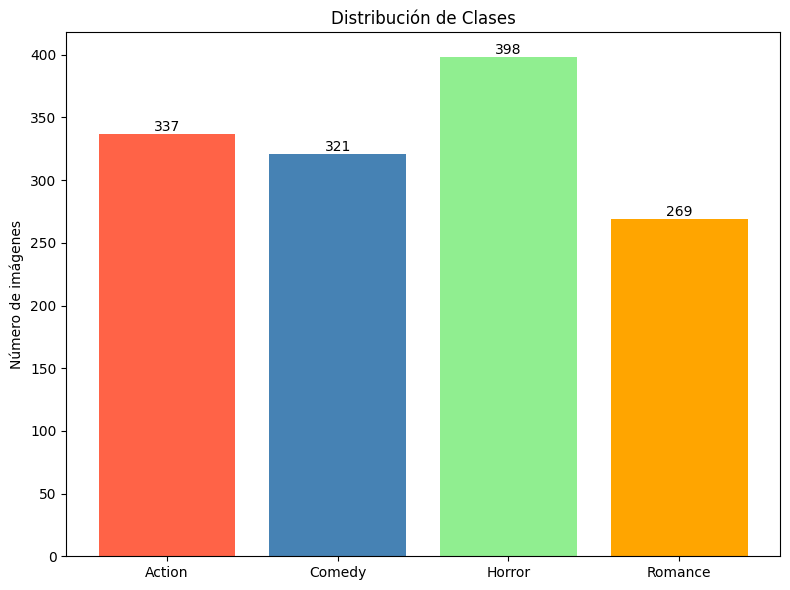

In [4]:
print(DATA_DIR)
IMG_SIZE = (80, 140)

action_paths = sorted(DATA_DIR.joinpath("Action").glob("*.jpg"))
comedy_paths = sorted(DATA_DIR.joinpath("Comedy").glob("*.jpg"))
horror_paths = sorted(DATA_DIR.joinpath("Horror").glob("*.jpg"))
romance_paths = sorted(DATA_DIR.joinpath("Romance").glob("*.jpg"))

n_action = len(action_paths)
n_comedy = len(comedy_paths)
n_horror = len(horror_paths)
n_romance = len(romance_paths)

print(f"Action: {n_action} imágenes")
print(f"Comedy: {n_comedy} imágenes")
print(f"Horror: {n_horror} imágenes")
print(f"Romance: {n_romance} imágenes")


_, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(
    ["Action", "Comedy", "Horror", "Romance"],
    [n_action, n_comedy, n_horror, n_romance],
    color=["tomato", "steelblue", "lightgreen", "orange"],
)
ax.set_title("Distribución de Clases")
ax.set_ylabel("Número de imágenes")
ax.bar_label(bars)
plt.tight_layout()
plt.show()

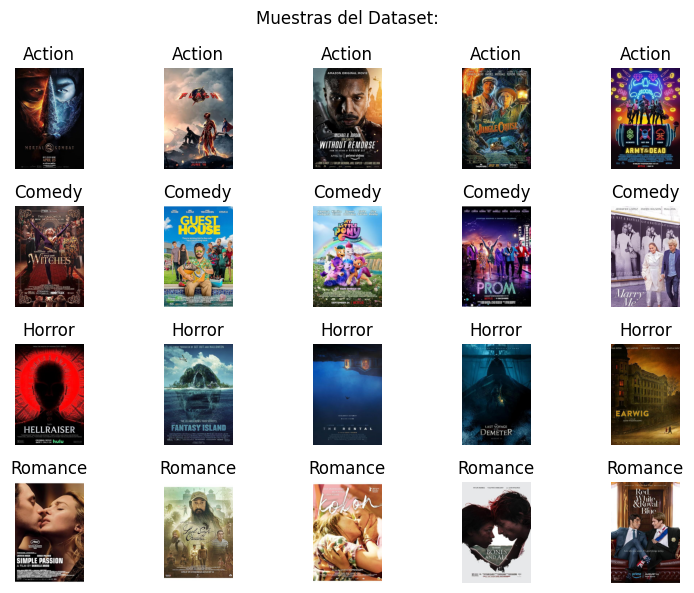

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(8, 6))
fig.suptitle("Muestras del Dataset:")

for i in range(5):
    img = Image.open(action_paths[i]).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].set_title("Action")
    axes[0, i].axis("off")

for i in range(5):
    img = Image.open(comedy_paths[i]).convert("RGB")
    axes[1, i].imshow(img)
    axes[1, i].set_title("Comedy")
    axes[1, i].axis("off")

for i in range(5):
    img = Image.open(horror_paths[i]).convert("RGB")
    axes[2, i].imshow(img)
    axes[2, i].set_title("Horror")
    axes[2, i].axis("off")

for i in range(5):
    img = Image.open(romance_paths[i]).convert("RGB")
    axes[3, i].imshow(img)
    axes[3, i].set_title("Romance")
    axes[3, i].axis("off")

plt.tight_layout()
plt.show()

# 3. Preprocesamiento de datos

En esta etapa aplicamos las técnicas de normalización, al pasar la escala de colores del rango [0, 255] al rango [0, 1]. Esto porque de esta manera espera recibir el dato la red neuronal implementada en keras. Por otro lado, estandarizamos las imágenes para que todas tengan el mismo tamaño de (380x562)px. Usamos el tamaño completo del poster. Asimismo, nos aseguramos que la representación matricial de todas las imagenes es de dtype=np.float32.

A continuación, dividimos nuestro dataset en tres partes: train, con el 70% de los datos. Validation, con el 15% de los datos, y Test, también con 15%. Esta partición se realiza estratificando teniendo en cuenta el label que queremos predecir. Esto para asegurarnos que nuestros tres conjuntos de datos están bien equilibrados.

In [6]:
def build_dataframe(paths_by_class):
    rows = [
        {"filepath": str(p), "label": c}
        for c, paths in paths_by_class.items()
        for p in paths
    ]
    return pd.DataFrame(rows)

df = build_dataframe({
    "Action":  action_paths,
    "Comedy":  comedy_paths,
    "Horror":  horror_paths,
    "Romance": romance_paths,
})

print(f"Total: {len(df)} imágenes")
print(df["label"].value_counts())


Total: 1325 imágenes
label
Horror     398
Action     337
Comedy     321
Romance    269
Name: count, dtype: int64


In [7]:
X = df[["filepath"]]
y = df["label"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.18, random_state=42, stratify=y_temp
)

print(f"Conjunto de entrenamiento: {len(X_train)} imágenes {len(X_train)/len(X):.2%}")
print(f"Conjunto de validación:    {len(X_val)} imágenes {len(X_val)/len(X):.2%}")
print(f"Conjunto de prueba:        {len(X_test)} imágenes {len(X_test)/len(X):.2%}")

Conjunto de entrenamiento: 923 imágenes 69.66%
Conjunto de validación:    203 imágenes 15.32%
Conjunto de prueba:        199 imágenes 15.02%


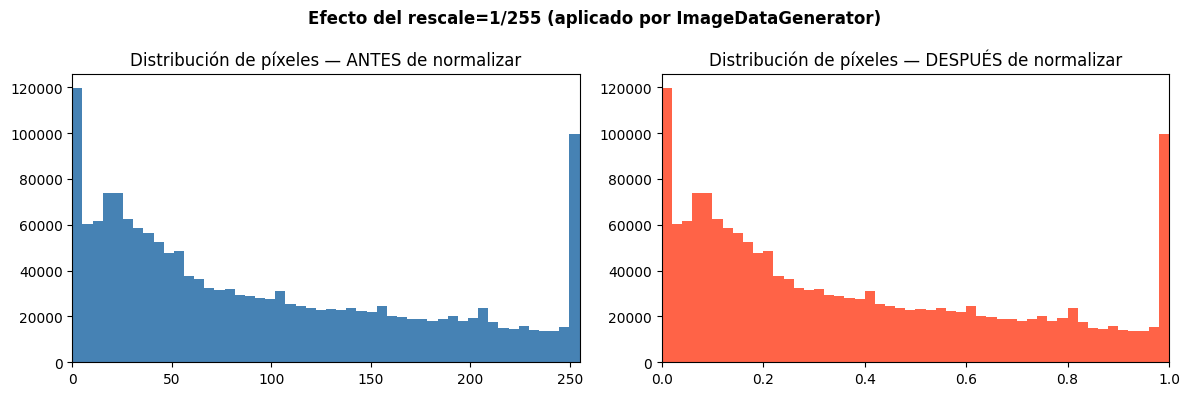

In [8]:
sample_paths = X_train["filepath"].sample(50, random_state=SEED).tolist()
sample_pixels = np.concatenate([
    np.array(Image.open(p).convert("RGB").resize(IMG_SIZE), dtype=np.float32).flatten()
    for p in sample_paths
])

_, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sample_pixels, bins=50, color="steelblue")
axes[0].set_title("Distribución de píxeles — ANTES de normalizar")
axes[0].set_xlim(0, 255)

axes[1].hist(sample_pixels / 255.0, bins=50, color="tomato")
axes[1].set_title("Distribución de píxeles — DESPUÉS de normalizar")
axes[1].set_xlim(0, 1)

plt.suptitle("Efecto del rescale=1/255 (aplicado por ImageDataGenerator)", fontweight="bold")
plt.tight_layout()
plt.show()


In [9]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CLASSES = ["Action", "Comedy", "Horror", "Romance"]
N_CLASSES = len(CLASSES)
BATCH_SIZE = 64

In [10]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0 / 255.0,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)
eval_datagen = keras.preprocessing.image.ImageDataGenerator(rescale=1.0 / 255.0)

def make_flow(datagen, X_split, y_split, shuffle):
    df = X_split.copy()
    df["label"] = y_split.values
    return datagen.flow_from_dataframe(
        dataframe=df,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        color_mode="rgb",
        class_mode="categorical",
        classes=CLASSES,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )


In [12]:
train = make_flow(train_datagen, X_train, y_train, shuffle=True)
val   = make_flow(eval_datagen,  X_val,   y_val,   shuffle=False)
test  = make_flow(eval_datagen,  X_test,  y_test,  shuffle=False)

classes_str = np.unique(y_train.values)
weights = compute_class_weight(
    class_weight="balanced", classes=classes_str, y=y_train.values
)
class_weight = {train.class_indices[c]: w for c, w in zip(classes_str, weights)}


Found 923 validated image filenames belonging to 4 classes.
Found 203 validated image filenames belonging to 4 classes.
Found 199 validated image filenames belonging to 4 classes.


# 4. Construcción del primer Modelo

### Explicación de la arquitectura:

En la capa de entrada, tenemos la imágen del poster, con sus tres canales RGB, y reescalada con el parámetro IMG_SIZE a un tamaño de 80x140px. Este tamaño mantiene la proporción de la imágen original, pero la encoge lo suficiente como para poder entrenar una red neuronal no demasiado grande en un computador no muy potente.

A continuación, tenemos tres capas convolucionales. Cada una de ellas aplica un filtro 3x3, del cual aprendemos los pesos. Tenemos para estas neuronas una función de activación relu, y a cada una de ellas le realizamos un BatchNormalization para que no estallen sus pesos. Realizamos un `padding="same"` para mantener el tamaño original de la imágen, o mapas, en cada capa antes de aplicar la siguiente serie de filtros. Mediante avanzan las capas, incrementamos el número de mapas. Esto es posible debido a que el pooling de la capa anterior nos redujo la dimensionalidad, de esta manera no incrementa demasiado el número de parámetros a aprender.

Finalmente, realizamos un aplanamiento de la salida de la última capa convolucional y pasamos a una red neuronal full connected, con 3 capas. La primera, con 128 neuronas, es la capa con más parámetros aprendibles en toda la red. Las siguientes capas reducen su número de neuronas a la mitad, con respecto a la anterior. También tienen una activación relu, pero además tienen un dropout del 30%, para evitar sobreajuste en esta parte. La predicción la realiza la última capa, la cual tiene 4 neuronas, para cuatro clases, y una función de activación softmax, para la clasificación.

In [12]:
model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    # layers.GlobalAveragePooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    
    layers.Dense(N_CLASSES, activation="softmax"),
])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 140, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 140, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 80, 140, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 70, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 70, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 70, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 40, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 35, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 20, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21760)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,785,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,890,020 (11.02 MB)

 Trainable params: 2,889,572 (11.02 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

## 4.1 Entrenamiendo del modelo

In [15]:
history = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=callbacks,
    #class_weight=class_weight,
)




Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - accuracy: 0.3120 - loss: 4.0313 - val_accuracy: 0.2562 - val_loss: 1.3799 - learning_rate: 0.0010
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step - accuracy: 0.3099 - loss: 1.8445 - val_accuracy: 0.2463 - val_loss: 1.3703 - learning_rate: 0.0010
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 257ms/step - accuracy: 0.3315 - loss: 1.3841 - val_accuracy: 0.2266 - val_loss: 1.3813 - learning_rate: 0.0010
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 259ms/step - accuracy: 0.3445 - loss: 1.3448 - val_accuracy: 0.2611 - val_loss: 1.3790 - learning_rate: 0.0010
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 256ms/step - accuracy: 0.3824 - loss: 1.3273 - val_accuracy: 0.4384 - val_loss: 1.3372 - learning_rate: 0.0010
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.3705 - loss: 1.2896 - val_accuracy: 0.3202 - val_loss: 1.3711 - learning_rate: 0.0010
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.3792 - loss: 1.2882 - 

In [16]:
test_loss, test_acc = model.evaluate(test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4523 - loss: 1.1911


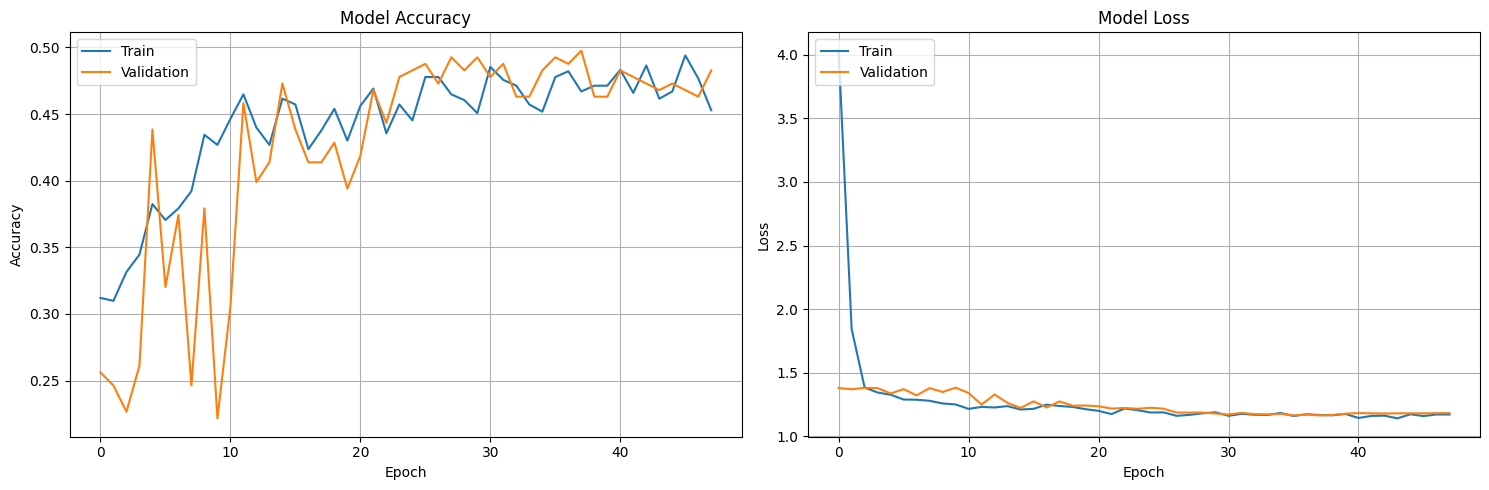

In [17]:
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


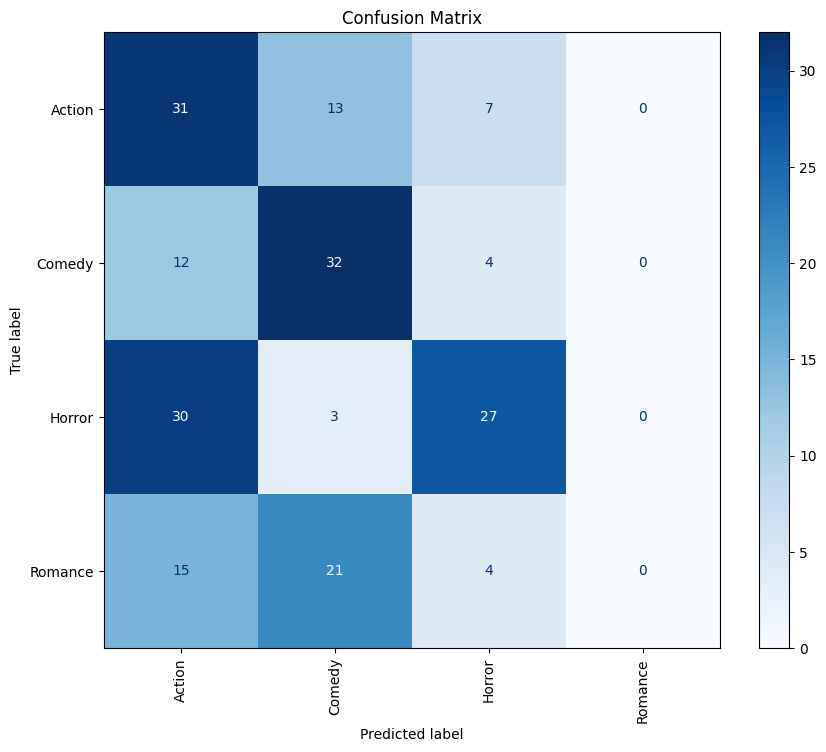

In [18]:
y_true = test.classes
y_pred_probabilities = model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [19]:
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     0.3523    0.6078    0.4460        51
      Comedy     0.4638    0.6667    0.5470        48
      Horror     0.6429    0.4500    0.5294        60
     Romance     0.0000    0.0000    0.0000        40

    accuracy                         0.4523       199
   macro avg     0.3647    0.4311    0.3806       199
weighted avg     0.3960    0.4523    0.4059       199



### El análisis de los resultados se hará más adelante, en conjunto con los resultados del modelo con búsqueda de hiperparámetros.


# 5. Búsqueda de hiperparámetros

Ahora realizaremos una búsqueda de hiperparámetros. Teniendo en cuenta que para realizar la búsqueda debemos entrenar múltiples modelos uno tras otro, usaremos modelos con menos capas que el primero entrenado. Esto para que no tarde demasiado el tuneo. Todos los modelos tendrán dos capas convolucionales, seguidos de dos capas densas. Lo que cambiará será el tamaño (número de filtros o neuronas) de las mismas. Asimismo, en las capas convolucionales probaremos filtros 3x3 y 5x5. Por otro lado, en las capas densas, probaremos con dropouts diferentes. Finalmente, probaremos tres diferentes learning rates para el entrenamiento.

In [13]:
def parameterSearch(hp):
    model = keras.Sequential([
        layers.Conv2D(
            filters=hp.Choice('filters_1', [32, 64]),
            kernel_size=hp.Choice('kernel_size_1', [3, 5]),
            padding='same',
            activation='relu',
            input_shape=(*IMG_SIZE, 3)
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            filters=hp.Choice('filters_2', [64, 128]),
            kernel_size=hp.Choice('kernel_size_2', [3, 5]),
            padding='same',
            activation='relu'
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(
            units=hp.Choice('dense_units', [128, 256]),
            activation='relu'
        ),
        layers.Dropout(hp.Float('dropout', 0.3, 0.5, step=0.1)),

        layers.Dense(
            units=hp.Choice('dense_units_2', [32, 64]),
            activation='relu'
        ),        
        layers.Dropout(hp.Float('dropout_2', 0.2, 0.3, step=0.1)),

        layers.Dense(4, activation='softmax')
    ])

    lr = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
tuner = kt.RandomSearch(
    parameterSearch,
    objective='val_accuracy',
    max_trials=15,
    directory='paramSearch_dir',
    project_name='cnn_param_tune'
)

In [18]:
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')

callbacks = [model_checkpoint, early_stopping, reduce_lr]

In [19]:
history = tuner.search(
    train,
    validation_data=val,
    epochs=15,
    callbacks=callbacks,
    # class_weight=class_weight
)

Trial 15 Complete [00h 01m 03s]
val_accuracy: 0.37931033968925476

Best val_accuracy So Far: 0.41871920228004456
Total elapsed time: 00h 14m 08s


In [21]:
best_model = tuner.get_best_models(1)[0]
best_model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 140, 64)    │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 140, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 70, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 44800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    11,469,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,528,068 (43.98 MB)

 Trainable params: 11,527,812 (43.98 MB)

 Non-trainable params: 256 (1.00 KB)

El modelo ganador es el siguiente:

```
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 80, 140, 64)    │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 80, 140, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 40, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 70, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 35, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 44800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    11,469,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
```

Como podemos ver, en general la búsqueda de hiperparámetros nos llevó a escoger el modelo más grande posible en términos de mapas y neuronas. En la primera capa convolucional 64 mapas, en la segunda también (esta es la única ocasión donde no se maximizó el número de neuronas). Posteriormente, en las capas densas, 256 y 64 neuronas, ambos el número máximo de neuronas que habíamos dispuesto. 

Este modelo tuvo un accuracy en el set de validación de 0.419. No es mejor que nuestro primer modelo entrenado, que era más grande, pero no se le queda tan atrás en todo caso.

In [22]:
history = best_model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=callbacks,
    #class_weight=class_weight
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 388ms/step - accuracy: 0.3694 - loss: 2.3898 - val_accuracy: 0.2956 - val_loss: 5.5821 - learning_rate: 5.0000e-04
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step - accuracy: 0.3738 - loss: 1.8972 - val_accuracy: 0.3005 - val_loss: 7.2890 - learning_rate: 5.0000e-04
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - accuracy: 0.3564 - loss: 1.5413 - val_accuracy: 0.3005 - val_loss: 6.5671 - learning_rate: 5.0000e-04
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 340ms/step - accuracy: 0.4171 - loss: 1.3538 - val_accuracy: 0.3005 - val_loss: 6.2509 - learning_rate: 5.0000e-04
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 337ms/step - accuracy: 0.3976 - loss: 1.3332 - val_accuracy: 0.3005 - val_loss: 6.8450 - learning_rate: 5.0000e-04
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.3681 - loss: 1.3141
Epoch 6: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step - accuracy: 0.37

In [23]:
test_loss, test_acc = best_model.evaluate(test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2915 - loss: 5.9996


In [26]:
def plot_training_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(history.history['accuracy'])
    axs[0].plot(history.history['val_accuracy'])
    axs[0].set_title('Model Accuracy')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].legend(['Train', 'Validation'], loc='upper left')
    axs[0].grid(True)
    axs[1].plot(history.history['loss'])
    axs[1].plot(history.history['val_loss'])
    axs[1].set_title('Model Loss')
    axs[1].set_ylabel('Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].legend(['Train', 'Validation'], loc='upper left')
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

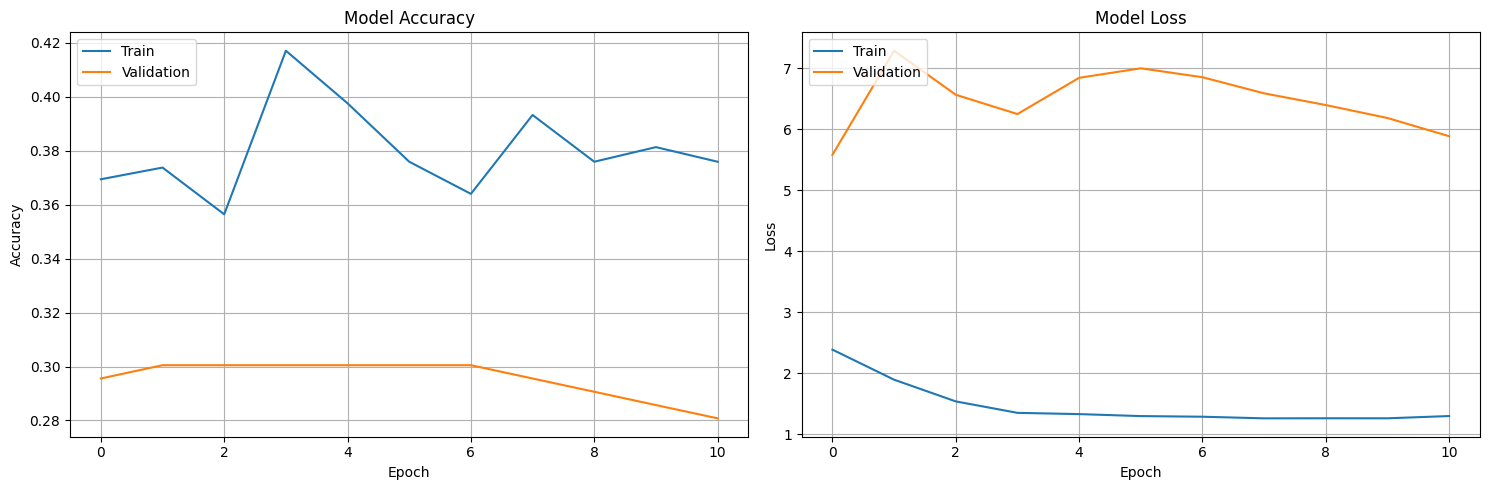

In [27]:
plot_training_history(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


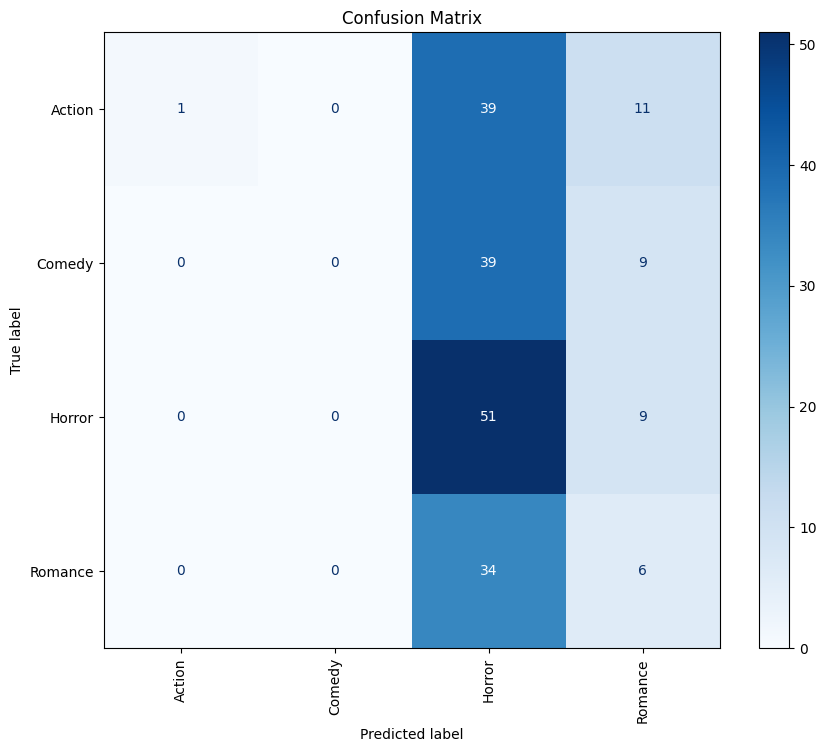

In [25]:
y_true = test.classes
y_pred_probabilities = best_model.predict(test)
y_pred = np.argmax(y_pred_probabilities, axis=1)
class_names = list(test.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)


fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix')
plt.show()

In [28]:
print(classification_report(
    y_true,
    y_pred,
    labels=range(len(class_names)),
    target_names=class_names,
    digits=4,
    zero_division=0
))

              precision    recall  f1-score   support

      Action     1.0000    0.0196    0.0385        51
      Comedy     0.0000    0.0000    0.0000        48
      Horror     0.3129    0.8500    0.4574        60
     Romance     0.1714    0.1500    0.1600        40

    accuracy                         0.2915       199
   macro avg     0.3711    0.2549    0.1640       199
weighted avg     0.3851    0.2915    0.1799       199



# 6. Análisis de los resultados.

En cuanto al modelo con búsqueda de hiperparámetros, como se mencionó antes, cuando se hizo el random search tuvimos un accuracy en el set de validación de 0.419. Sin embargo, cuando se reentrenó el modelo con más datos y epochs, obtuvimos un modelo bastante peor, con un val_accuracy de 0.2808. Esto nos recuerda la estocasticidad del proceso de entrenar una red neuronal. Por esta razón, decidimos dejarlo así. Este segundo modelo decidió que lo mejor era predecir casi todas las veces que la imagen pertenecía a la clase horror. Esto se debe a que la mayoría de las imágenes pertenecen a esta clase, hay un ligero desbalance. De esta manera, tal predicción le atina a la mayor cantidad de imagenes sin aprender nada. Se memoriza la estructura del dataset, no aprende a clasificar en verdad. De manera interesante, la mayor precisión la tuvo con la clase Action, para la cual solo generó una predicción, la cual fue correcta. Esto último nos hace ver que tomar una sola métrica (precission o recall) para decidir un modelo puede salir muy mal. Por esto preferimos una métrica que mezcle ambos y sea más completa, como el f1-score.

Para el primer modelo que entrenamos, tuvimos un f1-score con un weighted avg de 0.4059. Como podemos ver en la matriz de confusión asociada a ese modelo, decidió saltarse completamente la clase de romance, y generar predicciones únicamente para las otras tres. Esto puede deberse a que la clase romance era la más pequeña. La mayor precisión la logró con la clase Horror, mientras el mayor recall lo consiguió con romance, la clase que no decidió aprender. 

Somos consientes de que al momento de entrenar se le puede dar pesos a las clases `classweights`. Pero cuando lo hacíamos, el modelo simplemente prefería predecir que todas las imágenes eran romance, hasta para nuestro modelo más robusto, por lo que decidimos no usarlo en ningún entrenamiento en la entrega final.


Para mejorar el modelo, proponemos un incremento en la profundidad de la red, pues esta es la tendencia de escogencia que vimos en la búsqueda de hiperparámetros. Asimismo, proponemos una mejora en la calidad de las imágenes, esto es, un incremento en el input size. No pudimos hacer esto debido a nuestras restricciones computacionales. Por otro lado, un incremento en el tamaño de los datasets, asi como un balanceo en las clases, para evitar el problema explicado en el párrafo anterior.

Para concluir, en general notamos que nuestros modelos propuestos no son muy buenos para la clasificación de estas clases. Sin embargo, para ser honestos, consideramos que es una tarea bastante complicada, que si se quiere ser bien resuelta, necesitaría una arquitectura mucho más compleja. Asi como la capacidad de interpretar los títulos en los posters. Sin ellos, hasta a nosotros se nos complica clasificar la categoría de la película en algunas ocasiones.